In [16]:
import qbiome
from qbiome.data_formatter import DataFormatter
from qbiome.quantizer import Quantizer
from qbiome.qnet_orchestrator import QnetOrchestrator
from qbiome.forecaster import Forecaster
from qbiome.hypothesis import Hypothesis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("fivethirtyeight")
from qbiome.qutil import qsmooth

In [17]:
# File path to your merged CSV file
file_path = "example_data/merged_arg_gene_abundance.csv"  # update with actual path if needed

# Read the CSV into a DataFrame

merged_df = pd.read_csv(file_path,keep_default_na=False)

# Preview the first few rows
print(merged_df.head())

      CITY  relative_week  sample_id  blaOXA-58_1_AY665723  \
0  Bologna             58  1014216_1                    34   
1  Bologna             59  1014218_1                    29   
2  Bologna             61  1014220_1                    20   
3  Bologna             63  1014222_1                    46   
4  Bologna             65  1014224_1                    76   

   aph(3'')-Ib_2_AF024602  blaAER-1_1_U14748  aph(3')-Ia_3_EF015636  \
0                     448                 21                     13   
1                     472                 14                     31   
2                     298                 20                      4   
3                     379                 35                     12   
4                     399                 27                     20   

   blaTEM-1D_1_AF188200  tet(O/32/O)_5_FP929050  lnu(C)_1_AY928180  ...  \
0                    58                      56                 29  ...   
1                    81                      85   

In [18]:
import pandas as pd

# Assuming 'merged_df' is your original DataFrame (from first image)
long_df = merged_df.melt(
    id_vars=['sample_id', 'CITY', 'relative_week'],
    var_name='variable',
    value_name='value'
)

# Optionally rename columns to match second image format
long_df.rename(columns={
    'CITY': 'subject_id',
    'relative_week': 'week'
}, inplace=True)

# Reorder columns
long_df = long_df[['sample_id', 'subject_id', 'variable', 'value', 'week']]

# Preview the transformed DataFrame
print(long_df.head())

   sample_id subject_id              variable  value  week
0  1014216_1    Bologna  blaOXA-58_1_AY665723     34    58
1  1014218_1    Bologna  blaOXA-58_1_AY665723     29    59
2  1014220_1    Bologna  blaOXA-58_1_AY665723     20    61
3  1014222_1    Bologna  blaOXA-58_1_AY665723     46    63
4  1014224_1    Bologna  blaOXA-58_1_AY665723     76    65


In [19]:
data= long_df
data

,sample_id,subject_id,variable,value,week
0,1014216_1,Bologna,blaOXA-58_1_AY665723,34,58
1,1014218_1,Bologna,blaOXA-58_1_AY665723,29,59
2,1014220_1,Bologna,blaOXA-58_1_AY665723,20,61
3,1014222_1,Bologna,blaOXA-58_1_AY665723,46,63
4,1014224_1,Bologna,blaOXA-58_1_AY665723,76,65
...,...,...,...,...,...
130185,1014209_1,Rotterdam,blaSGM-4_1_CP002798,0,138
130186,1014210_1,Rotterdam,blaSGM-4_1_CP002798,0,139
130187,1014211_1,Rotterdam,blaSGM-4_1_CP002798,0,140
130188,1014213_1,Rotterdam,blaSGM-4_1_CP002798,0,142


In [20]:
print(data.value.min(), data.value.max())

0 9449


In [21]:
data['value'] = np.log2(data['value'] + 1)

In [22]:
data

,sample_id,subject_id,variable,value,week
0,1014216_1,Bologna,blaOXA-58_1_AY665723,5.129283,58
1,1014218_1,Bologna,blaOXA-58_1_AY665723,4.906891,59
2,1014220_1,Bologna,blaOXA-58_1_AY665723,4.392317,61
3,1014222_1,Bologna,blaOXA-58_1_AY665723,5.554589,63
4,1014224_1,Bologna,blaOXA-58_1_AY665723,6.266787,65
...,...,...,...,...,...
130185,1014209_1,Rotterdam,blaSGM-4_1_CP002798,0.000000,138
130186,1014210_1,Rotterdam,blaSGM-4_1_CP002798,0.000000,139
130187,1014211_1,Rotterdam,blaSGM-4_1_CP002798,0.000000,140
130188,1014213_1,Rotterdam,blaSGM-4_1_CP002798,0.000000,142


In [23]:
len(data.variable.unique())

554

In [24]:
len(data.week.unique())

95

In [25]:
base_tax = "Time_Series_ARG_log"

In [26]:
biome=data.variable.values[1]
biome

'blaOXA-58_1_AY665723'

In [ ]:
quantizer = Quantizer(num_levels=26)
qnet_orchestrator = QnetOrchestrator(quantizer)
quantized = quantizer.quantize_df(data)


In [ ]:
quantized

In [ ]:
quantized["ARR-3_4_FM207631_0"].unique()

In [ ]:
features, label_matrix = quantizer.get_qnet_inputs(quantized)

In [ ]:
display(features)
display(label_matrix)

In [ ]:
features

In [ ]:
label_matrix.shape

In [ ]:
TAXA = list(data.variable.value_counts().index.values)


In [ ]:
%%time
qnet_orchestrator.train_qnet(
    features, label_matrix, alpha=0.3, min_samples_split=2, out_fname=None
)


In [ ]:
%%time
qnet_orchestrator.save_qnet("example_qnet_"+base_tax+".pkl",GZIP=True)

In [ ]:
print("hello")

In [ ]:
# from quasinet.qnet import load_qnet
# outdirname = 'trees_'+base_tax
# modelpath="example_qnet_"+base_tax+".pkl.gz"
# model=load_qnet(modelpath,gz=True)
# model.viz_trees(tree_path=outdirname,big_enough_threshold=1,format='png',
#                 remove_newline=True,remove_dotfile=True)

In [ ]:
# from IPython.display import Image
# import glob
# Image(filename=glob.glob(outdirname+"/*png")[0])

### Inspect Positive and Negative Regulation (LOMAR coefficients)

In [141]:
# qnet_orchestrator.load_qnet("example_qnet_"+base_tax+".pkl.gz",GZIP=True)
# hypothesis = Hypothesis(
#     quantizer=quantizer,qnet_orchestrator=qnet_orchestrator, detailed_labels=True
# )

In [144]:
# hypothesis.causal_constraint = -2
# hypothesis.no_self_loops = False

# hypothesis.get(time_start=60, time_end=90)
# hypothesis.to_dot("hypothesis_1_10.dot")
# hypothesis.hypotheses.sort_values("src")

100%|██████████| 45/45 [00:23<00:00,  1.89it/s]


,src,tgt,time_tgt,lomar,pvalue
216,Acidovorax,UBA1413,77.0,0.004568,0.000000e+00
251,Acidovorax,Acinetobacter,68.0,0.636408,0.000000e+00
34,Acidovorax,Paracoccus,67.0,-0.028615,0.000000e+00
369,Acidovorax,Ottowia,78.0,0.057299,2.747262e-125
57,Acinetobacter,merged,73.0,-7.627334,0.000000e+00
...,...,...,...,...,...
331,merged,Aliarcobacter,77.0,0.234674,0.000000e+00
265,merged,Microthrix,80.0,0.000241,0.000000e+00
284,merged,Tolumonas,83.0,0.008914,0.000000e+00
28,merged,Paracoccus,78.0,-0.001788,0.000000e+00


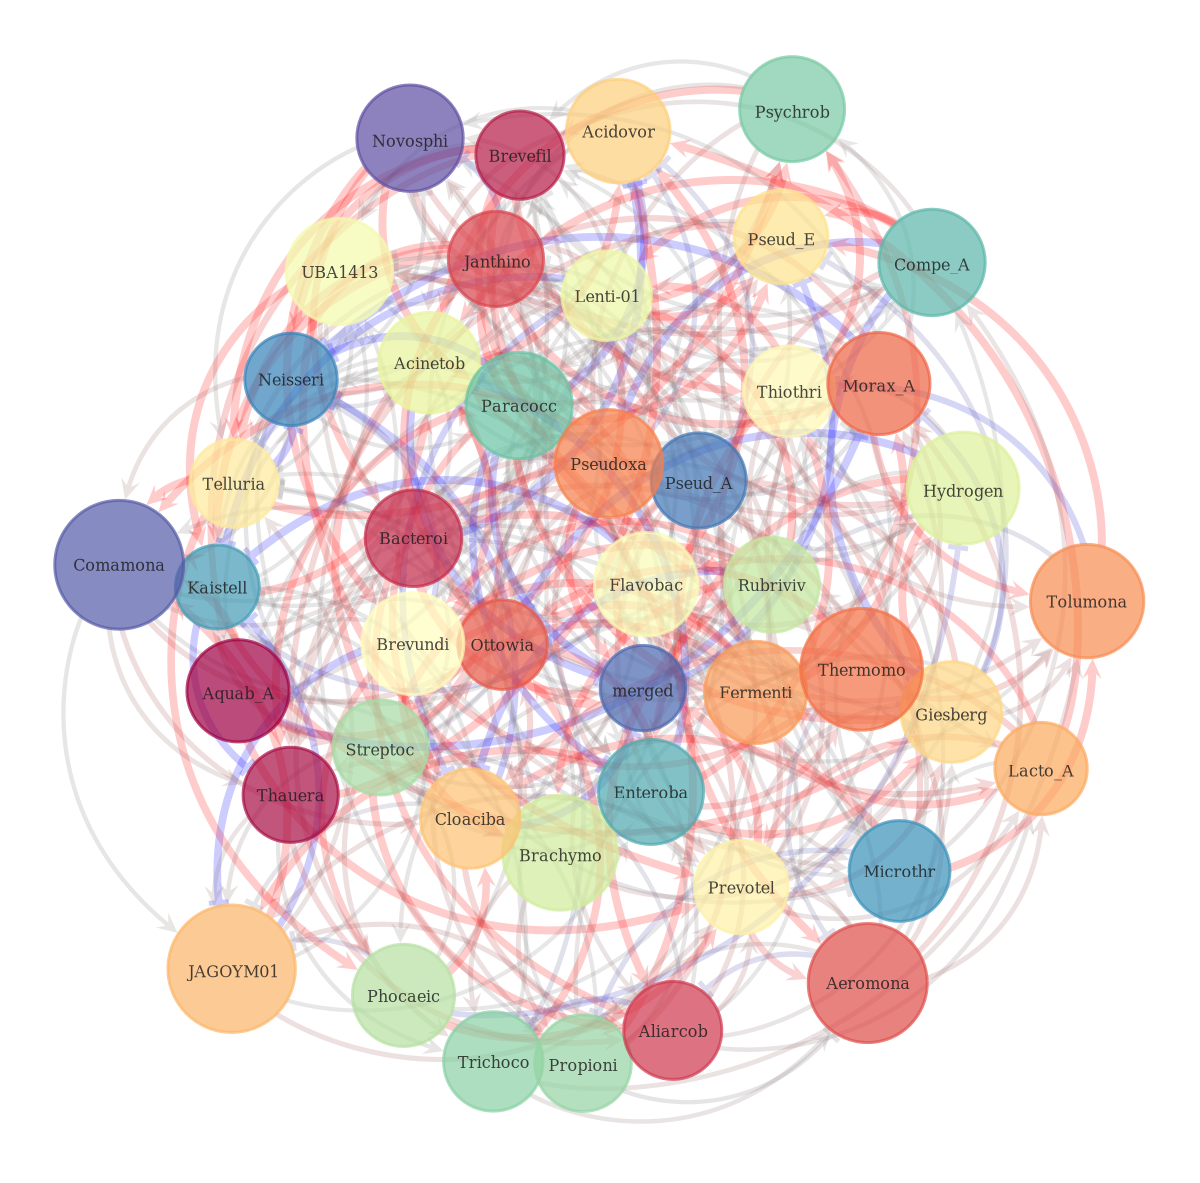

In [145]:
# # if graph-tool is installed
# from qbiome.network import Network
# Network('hypothesis_1_10.dot',outfile='net.png').get()
# # Can also use the external prog
# #! python3.7 plotNetwork.py >& /dev/null
# from IPython.display import Image
# Image(filename='net.png')

### Forecast microbiome evolutionary trajectories

In [22]:
# qnet_orchestrator.load_qnet("example_qnet_"+base_tax+".pkl.gz",GZIP=True)

# --- Step 6: Load trained Q-net model ---
qnet_orchestrator = QnetOrchestrator(quantizer)
qnet_orchestrator.load_qnet("example_qnet_" + base_tax + ".pkl.gz", GZIP=True)


In [38]:
# from qbiome.quantizer import Quantizer
# from qbiome.qnet_orchestrator import QnetOrchestrator
# from qbiome.forecaster import Forecaster
# import pandas as pd

# # --- Step 1: Define key components ---
# # Existing long-format dataframe with rel_abundance values
# # Assumes your DataFrame is named `data` and has columns:
# # 'subject_id', 'week', 'variable', 'value'

# # Unique subjects and taxa
# subjects = data['subject_id'].unique()
# taxa     = data['variable'].unique()

# # Target forecast window
# future_weeks = range(91, 101)

# # --- Step 2: Pad future weeks with empty labels ("" = missing) ---
# pad = (pd.MultiIndex.from_product([subjects, future_weeks, taxa],
#                                   names=['subject_id', 'week', 'variable'])
#        .to_frame(index=False))
# pad['value'] = ""  # Placeholder to indicate "missing" in quantized form

# # --- Step 3: Quantize observed abundances (60–90) ---
# quantizer = Quantizer(num_levels=10)  # Use same num_levels as training
# quantized_df = quantizer.quantize_df(data)

# # --- Step 4: Merge observed + padded future weeks ---
# quantized_df = pd.concat([quantized_df, pad], ignore_index=True)

# # --- Step 5: Convert to label_matrix for forecasting ---
# features, label_matrix = quantizer.get_qnet_inputs(quantized_df)



In [20]:
# quantized_df

NameError: name 'quantized_df' is not defined

In [23]:
# display(features)

Index(['Acidovorax_60', 'Acidovorax_61', 'Acidovorax_62', 'Acidovorax_63',
       'Acidovorax_64', 'Acidovorax_65', 'Acidovorax_66', 'Acidovorax_67',
       'Acidovorax_68', 'Acidovorax_69',
       ...
       'UBA1413_81', 'UBA1413_82', 'UBA1413_83', 'UBA1413_84', 'UBA1413_85',
       'UBA1413_86', 'UBA1413_87', 'UBA1413_88', 'UBA1413_89', 'UBA1413_90'],
      dtype='object', length=1320)

In [22]:
# # --- Step 7: Forecast weeks 91–100 ---
# SW, EW = 90, 100  # Start from last known week
# forecaster = Forecaster(qnet_orchestrator)
# forecasted_ = (forecaster
#                .forecast_data(label_matrix, start_week=SW, end_week=EW)
#                .assign(source="forecasted"))

# # --- Step 9: Inspect results ---
# print(forecasted_.week.unique())      # should show [91, ..., 100]
# print(forecasted_.head())             # preview some predictions


[60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 77 78 79 80 81 82 83 84
 85 86 87 88 89 90]
      subject_id    variable  week     value      source
0        Bologna  Acidovorax    60       NaN  forecasted
1       Budapest  Acidovorax    60       NaN  forecasted
2  Copenaghen_RA  Acidovorax    60       NaN  forecasted
3  Copenaghen_RD  Acidovorax    60  0.169878  forecasted
4  Copenaghen_RL  Acidovorax    60  0.222480  forecasted


In [23]:
quantized

,subject_id,Acidovorax_60,Acidovorax_61,Acidovorax_62,Acidovorax_63,Acidovorax_64,Acidovorax_65,Acidovorax_66,Acidovorax_67,Acidovorax_68,...,UBA1413_81,UBA1413_82,UBA1413_83,UBA1413_84,UBA1413_85,UBA1413_86,UBA1413_87,UBA1413_88,UBA1413_89,UBA1413_90
0,Bologna,NaN,J,NaN,G,NaN,J,NaN,J,NaN,...,J,NaN,A,NaN,A,NaN,NaN,A,E,NaN
1,Budapest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,A,...,NaN,NaN,A,E,NaN,NaN,J,NaN,NaN,E
2,Copenaghen_RA,NaN,A,NaN,NaN,H,A,NaN,F,F,...,B,D,NaN,NaN,NaN,A,NaN,NaN,NaN,NaN
3,Copenaghen_RD,A,B,NaN,NaN,I,D,NaN,J,C,...,NaN,J,NaN,NaN,NaN,D,NaN,NaN,NaN,NaN
4,Copenaghen_RL,J,J,NaN,A,J,G,NaN,J,F,...,A,D,NaN,NaN,NaN,J,NaN,NaN,NaN,NaN
5,Rome,G,NaN,J,J,NaN,NaN,E,NaN,J,...,NaN,A,J,NaN,J,NaN,A,NaN,NaN,J
6,Rotterdam,NaN,NaN,A,NaN,A,G,NaN,NaN,A,...,A,NaN,A,NaN,NaN,A,NaN,J,NaN,A


In [24]:
SW = 60
EW = 90
#qnet_orchestrator = QnetOrchestrator(quantizer)
#qnet_orchestrator.load_qnet("example_qnet.pkl.gz",GZIP=True)
forecaster = Forecaster(qnet_orchestrator)
# can specify an end week or default to the max end week in the data
forecasted_ = forecaster.forecast_data(label_matrix, start_week=SW, end_week=EW).assign(
    source="forecasted"
)

In [25]:
forecasted_.week.unique()

array([60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 77,
       78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90])

In [26]:
biome=data.variable.values[3]
biome

'Aliarcobacter'

In [27]:
DF = forecasted_
SUBJECTS = DF.subject_id.value_counts().index.values
DF

DF_pop = DF.groupby(["variable", "week"]).mean(numeric_only=True).reset_index()
DF_data = data.groupby(["variable", "week"]).mean(numeric_only=True).reset_index()

In [28]:
SUBJECTS

array(['Bologna', 'Budapest', 'Copenaghen_RA', 'Copenaghen_RD',
       'Copenaghen_RL', 'Rome', 'Rotterdam'], dtype=object)

In [188]:
DF.week.unique()

array([60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 77,
       78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90])

In [29]:
DF

,subject_id,variable,week,value,source
0,Bologna,Acidovorax,60,0.199114,forecasted
1,Budapest,Acidovorax,60,0.204955,forecasted
2,Copenaghen_RA,Acidovorax,60,0.199114,forecasted
3,Copenaghen_RD,Acidovorax,60,0.199114,forecasted
4,Copenaghen_RL,Acidovorax,60,0.199114,forecasted
...,...,...,...,...,...
9235,Copenaghen_RA,UBA1413,90,0.000007,forecasted
9236,Copenaghen_RD,UBA1413,90,0.000007,forecasted
9237,Copenaghen_RL,UBA1413,90,0.000008,forecasted
9238,Rome,UBA1413,90,0.000008,forecasted


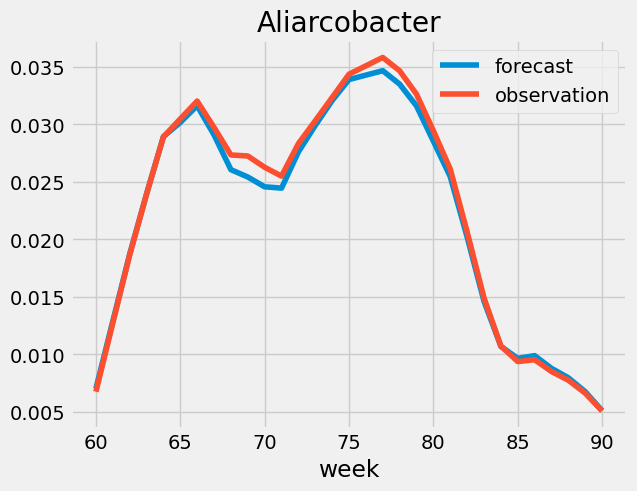

In [30]:
DF_pop = DF.groupby(["variable", "week"]).mean(numeric_only=True).reset_index()
DF_data = data.groupby(["variable", "week"]).mean(numeric_only=True).reset_index()

DF_pop_smooth = qsmooth(
    DF_pop,
    index="week",
    columns="variable",
    normalize=False,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.3,
)

# DF_data_smooth
DF_data_smooth = qsmooth(
    DF_data,
    index="week",
    columns="variable",
    normalize=False,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.3,
)

ax = DF_pop_smooth[biome].plot(label="forecast")
DF_data_smooth[biome].plot(ax=ax, label="observation")
ax.set_title(biome)
ax.legend()

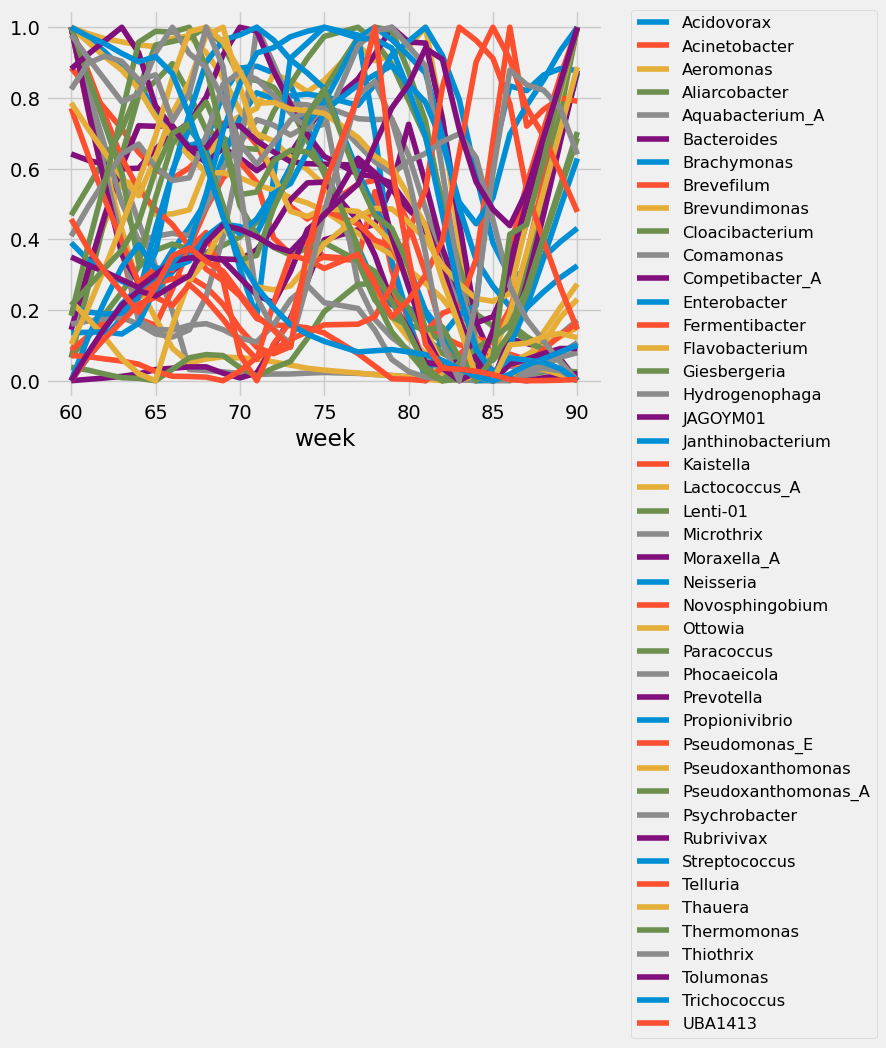

In [33]:
DF_pop = DF.groupby(["variable", "week"]).mean(numeric_only=True).reset_index()
DF_data = data.groupby(["variable", "week"]).mean(numeric_only=True).reset_index()

DF_pop_smooth = qsmooth(
    DF_pop,
    index="week",
    columns="variable",
    normalize=True,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.3,
)

# DF_data_smooth
DF_data_smooth = qsmooth(
    DF_data,
    index="week",
    columns="variable",
    normalize=True,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.3,
)

ax = DF_pop_smooth.plot(label="forecast")
# DF_data_smooth[biome].plot(ax=ax, label="observation")
ax.set_title(biome)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize='small', ncol=1)
plt.tight_layout()

In [286]:
test_df_grouped = (
    test_df
    .groupby(["variable", "week"])
    .mean(numeric_only=True)
    .reset_index()
)

In [288]:
test_df_smooth = qsmooth(
    test_df_grouped,
    index="week",
    columns="variable",
    normalize=False,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.4,
)


<Axes: xlabel='week'>

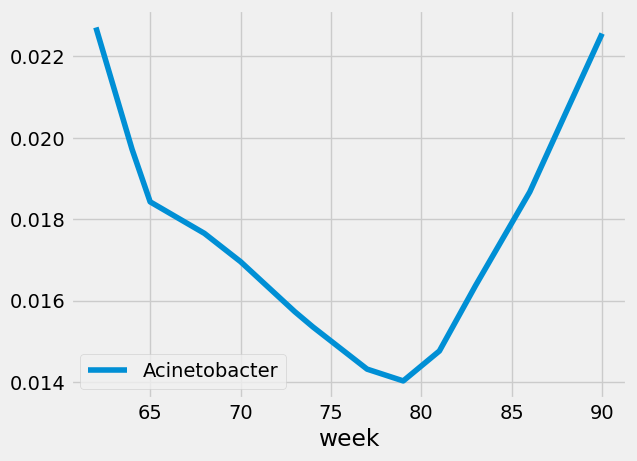

In [289]:
test_df_smooth.plot()

In [239]:
data[data.subject_id == SID]


,sample_id,subject_id,variable,value,week
4545,1014139_1,Rotterdam,Acidovorax,0.116992,62
4546,1014139_1,Rotterdam,Acinetobacter,0.024421,62
4547,1014139_1,Rotterdam,Aeromonas,0.011880,62
4548,1014139_1,Rotterdam,Aliarcobacter,0.014876,62
4549,1014139_1,Rotterdam,Aquabacterium_A,0.000422,62
...,...,...,...,...,...
5169,1014166_1,Rotterdam,Thermomonas,0.010926,90
5170,1014166_1,Rotterdam,Thiothrix,0.004042,90
5171,1014166_1,Rotterdam,Tolumonas,0.026276,90
5172,1014166_1,Rotterdam,Trichococcus,0.003335,90


In [ ]:
ax = DF_pop_smooth[var].plot(label="forecast")
DF_data_smooth[var].plot(ax=ax, style="o", ms=5, label="observation")
ax.set_title(biome +"_" +SID)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

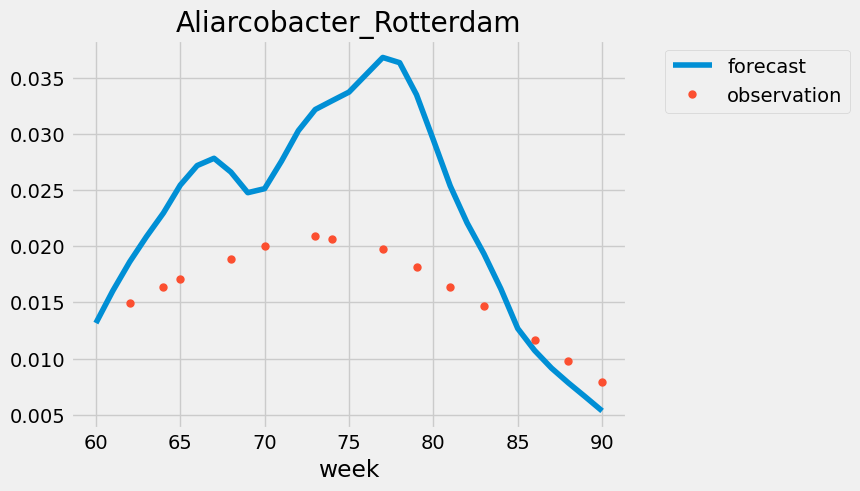

In [228]:
SID = "Rotterdam" #'Bologna', 'Budapest', 'Copenaghen_RA', 'Copenaghen_RD','Copenaghen_RL', 'Rome', 'Rotterdam']
DF_pop = (
    DF[DF.subject_id == SID]
    .groupby(["variable", "week"])
    .mean(numeric_only=True)
    .reset_index()
)
DF_data = (
    data[data.subject_id == SID]
    .groupby(["variable", "week"])
    .mean(numeric_only=True)
    .reset_index()
)
DF_pop_smooth = qsmooth(
    DF_pop,
    index="week",
    columns="variable",
    normalize=False,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.4,
)

# DF_data_smooth
DF_data_smooth = qsmooth(
    DF_data,
    index="week",
    columns="variable",
    normalize=False,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.6,
)

var = biome
ax = DF_pop_smooth[var].plot(label="forecast")
DF_data_smooth[var].plot(ax=ax, style="o", ms=5, label="observation")
ax.set_title(biome +"_" +SID)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

In [124]:
new_subject = DF[DF.subject_id == SID][["week","variable","value"]]
new_subject

,week,variable,value
5,60,Acidovorax,0.199114
12,61,Acidovorax,0.130982
19,62,Acidovorax,0.179373
26,63,Acidovorax,0.185913
33,64,Acidovorax,0.168911
...,...,...,...
9420,86,merged,0.327158
9427,87,merged,0.411606
9434,88,merged,0.460003
9441,89,merged,0.033917


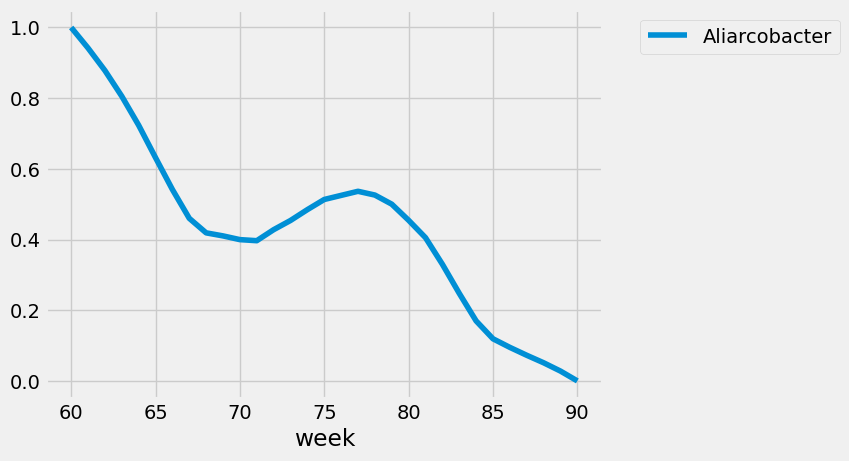

In [127]:

new_subject_quantized = quantizer.quantize_new_subject(new_subject, subject_id=12345)
_, new_subject_matrix = quantizer.get_qnet_inputs(new_subject_quantized)
new_subject_forecasted = forecaster.forecast_data( 
    new_subject_matrix, start_week=SW+90, subject_id=["Bologna"], n_samples=50
)

df_ = qsmooth(
    new_subject_forecasted.drop("subject_id", axis=1),
    index="week",
    columns="variable",
    interpolate=False,
    alpha=0.5,
    lowess_fraction=0.3,
    normalize=True,
)


ax = df_[biome].plot()
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

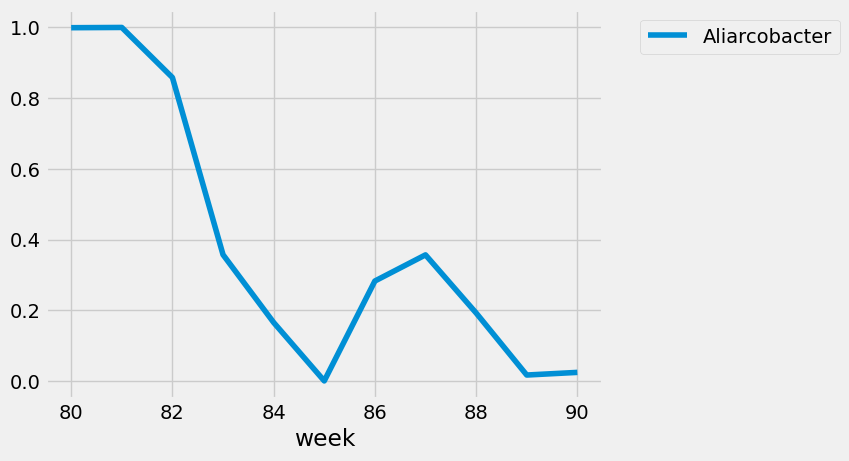

In [129]:
new_subject = pd.DataFrame(
    {
        "week": [60] * len(TAXA),
        "variable": TAXA,
        "value": np.random.rand(len(TAXA)),
    }
)


new_subject_quantized = quantizer.quantize_new_subject(new_subject, subject_id=SID)
_, new_subject_matrix = quantizer.get_qnet_inputs(new_subject_quantized)
new_subject_forecasted = forecaster.forecast_data( 
    new_subject_matrix, start_week=SW+20, subject_id=["Bologna"], n_samples=500
)

df_ = qsmooth(
    new_subject_forecasted.drop("subject_id", axis=1),
    index="week",
    columns="variable",
    interpolate=False,
    alpha=0.5,
    lowess_fraction=0.3,
    normalize=True,
)

ax = df_[biome].plot()
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

In [121]:
new_subject

,week,variable,value,subject_id
0,90,Acidovorax,0.684844,12345
1,90,Acinetobacter,0.865567,12345
2,90,Aeromonas,0.551120,12345
3,90,Aliarcobacter,0.055364,12345
4,90,Aquabacterium_A,0.224555,12345
5,90,Bacteroides,0.928987,12345
6,90,Brachymonas,0.880572,12345
7,90,Brevefilum,0.891120,12345
8,90,Brevundimonas,0.833107,12345
9,90,Cloacibacterium,0.372791,12345


### Generate Ecosystem Evolution for a Non-existant "Phantom" Patient

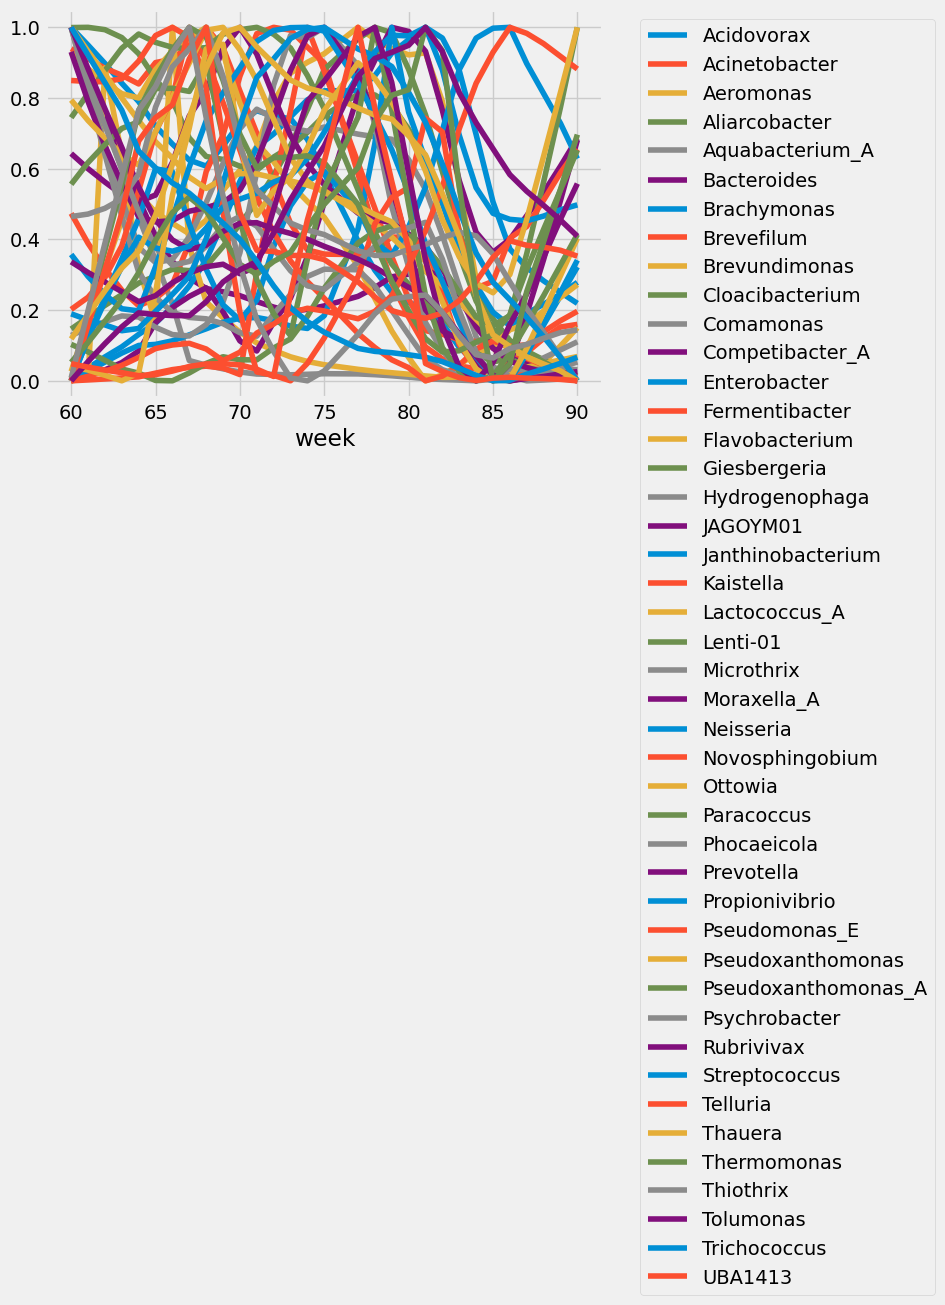

In [31]:
new_subject = pd.DataFrame(
    {
        "week": [0] * len(TAXA),
        "variable": TAXA,
        "value": [np.nan]*len(TAXA),
    }
)
new_subject_quantized = quantizer.quantize_new_subject(new_subject, subject_id=12345)
_, new_subject_matrix = quantizer.get_qnet_inputs(new_subject_quantized)
new_subject_forecasted = forecaster.forecast_data(
    new_subject_matrix, start_week=SW, subject_id=[12345]
)

df_ = qsmooth(
    new_subject_forecasted.drop("subject_id", axis=1),
    index="week",
    columns="variable",
    interpolate=False,
    alpha=0.5,
    lowess_fraction=0.3,
    normalize=True,
)

ax = df_.plot()
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

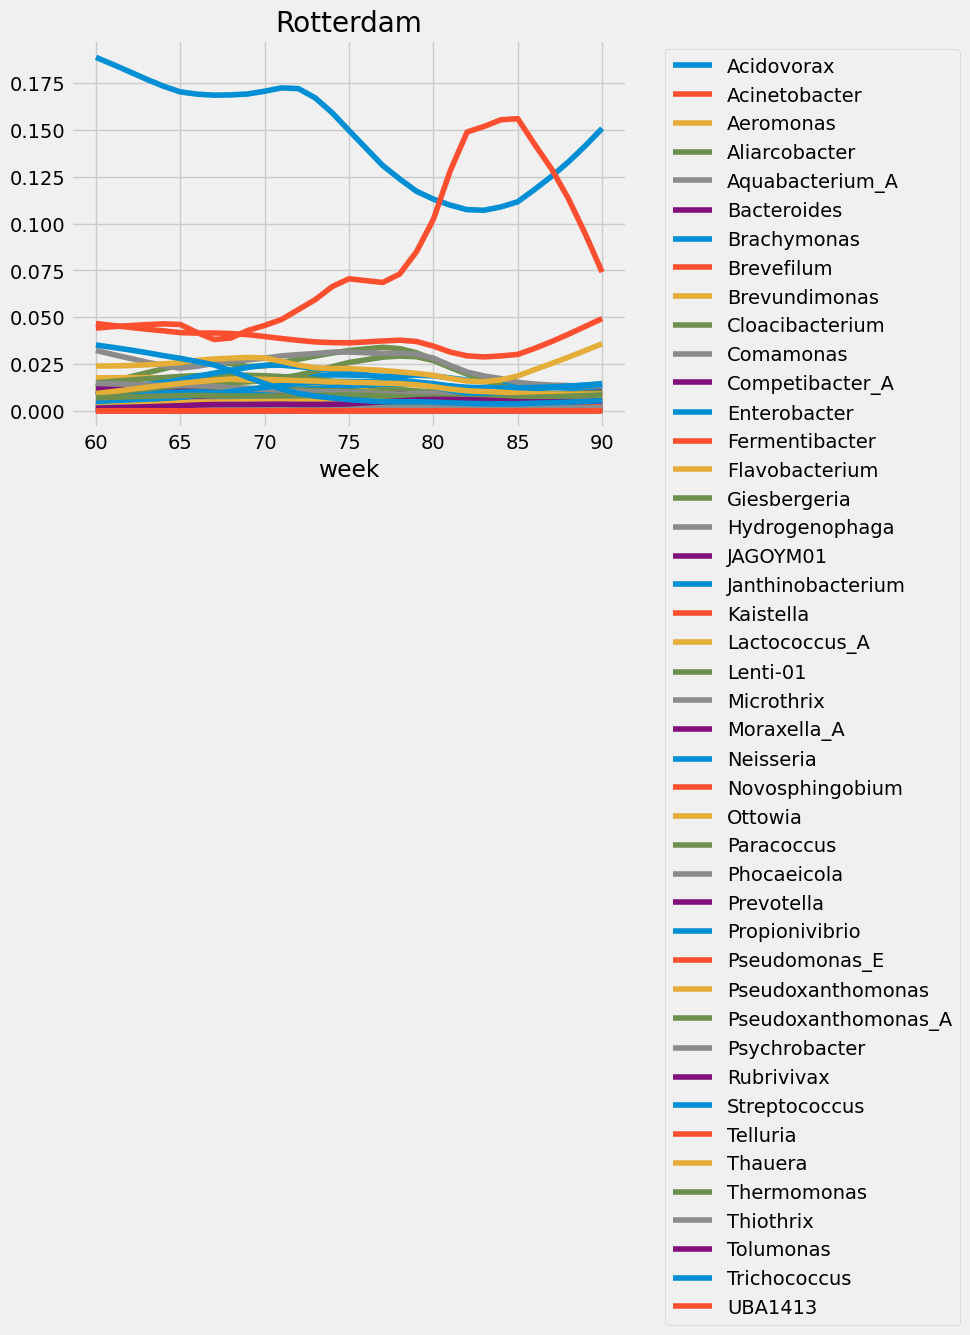

In [42]:
SID = "Rotterdam" #'Bologna', 'Budapest', 'Copenaghen_RA', 'Copenaghen_RD','Copenaghen_RL', 'Rome', 'Rotterdam']
DF_pop = (
    DF[DF.subject_id == SID]
    .groupby(["variable", "week"])
    .mean(numeric_only=True)
    .reset_index()
)
DF_data = (
    data[data.subject_id == SID]
    .groupby(["variable", "week"])
    .mean(numeric_only=True)
    .reset_index()
)
DF_pop_smooth = qsmooth(
    DF_pop,
    index="week",
    columns="variable",
    normalize=False,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.4,
)

# DF_data_smooth
DF_data_smooth = qsmooth(
    DF_data,
    index="week",
    columns="variable",
    normalize=False,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.6,
)

var = biome
ax = DF_pop_smooth.plot(label="forecast")
# DF_data_smooth[var].plot(ax=ax, style="o", ms=5, label="observation")
ax.set_title(SID)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")